## Importación de librerías

In [11]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

%matplotlib inline
sns.set_theme()

## Carga del dataset

In [12]:

df_train = pd.read_csv('../../../dataset/oulad/generated/dataset_train_2013_full_30d.csv')
df_test = pd.read_csv('../../../dataset/oulad/generated/dataset_test_2014_full_30d.csv')

columnas_sensibles = ['gender', 'region', 'imd_band', 'age_band', 'disability']
df_train = df_train.drop(columns=columnas_sensibles, errors='ignore')
df_test = df_test.drop(columns=columnas_sensibles, errors='ignore')

df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

X_train = df_train.drop(columns=['target_burnout'], errors='ignore')
y_train = df_train['target_burnout']
X_test = df_test.drop(columns=['target_burnout'], errors='ignore')
y_test = df_test['target_burnout']

print("--- DISTRIBUCIÓN ORIGINAL (30 DÍAS | SIN DATOS SENSIBLES) ---")
print(f"Train 2013 - Total: {len(X_train)} | Riesgo (1): {y_train.sum()} | Éxito (0): {len(y_train) - y_train.sum()}")
print(f"Test 2014  - Total: {len(X_test)} | Riesgo (1): {y_test.sum()} | Éxito (0): {len(y_test) - y_test.sum()}")

--- DISTRIBUCIÓN ORIGINAL (30 DÍAS | SIN DATOS SENSIBLES) ---
Train 2013 - Total: 11142 | Riesgo (1): 3348 | Éxito (0): 7794
Test 2014  - Total: 10801 | Riesgo (1): 3693 | Éxito (0): 7108


## Entrenamieto

In [13]:
cat_cols = ['highest_education']
num_cols = [
    'num_of_prev_attempts', 'studied_credits',
    'total_clicks_30d', 'media_clicks_semanales', 'total_dias_activos',
    'semanas_con_actividad', 'semanas_actividad_plena', 'max_clicks_1_dia',
    'semanas_sin_clicks', 'dias_sin_clicks_30d',
    'entregas_realizadas_30d', 'nota_media_30d', 'retraso_medio_dias', 'total_entregas_tardias',
    'clicks_semana_0', 'clicks_semana_1', 'clicks_semana_2', 'clicks_semana_3', 'clicks_semana_4'
]


from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

peso_minoritaria = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
print(f"Ratio de desbalanceo ajustado (scale_pos_weight): {peso_minoritaria:.2f}")

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        learning_rate=0.1,
        max_depth=3,
        min_child_weight=10,
        n_estimators=100,
        scale_pos_weight=peso_minoritaria, 
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred = xgb_pipeline.predict(X_test)

print("¡Entrenamiento de XGBoost (Línea Base Sin Datos Sensibles) finalizado con éxito!")

Ratio de desbalanceo ajustado (scale_pos_weight): 2.33
¡Entrenamiento de XGBoost (Línea Base Sin Datos Sensibles) finalizado con éxito!


## Evaluación y Gráficas de Rendimiento

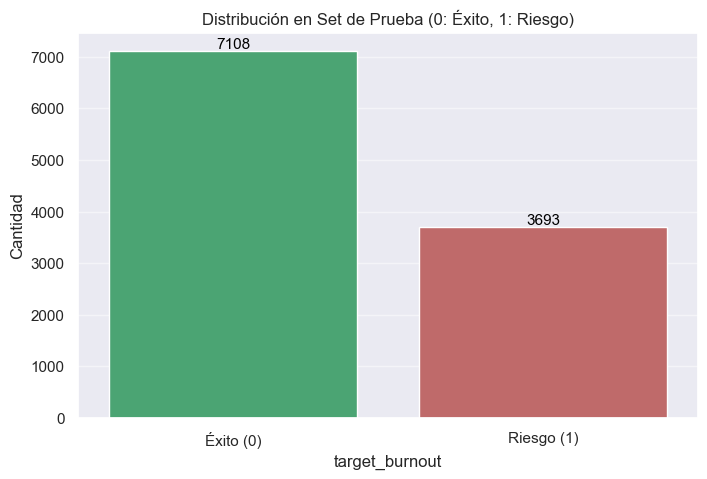

--- REPORTE DE CLASIFICACIÓN DETALLADO (Umbral: 0.53) ---
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      7108
           1       0.67      0.66      0.67      3693

    accuracy                           0.77     10801
   macro avg       0.75      0.75      0.75     10801
weighted avg       0.77      0.77      0.77     10801



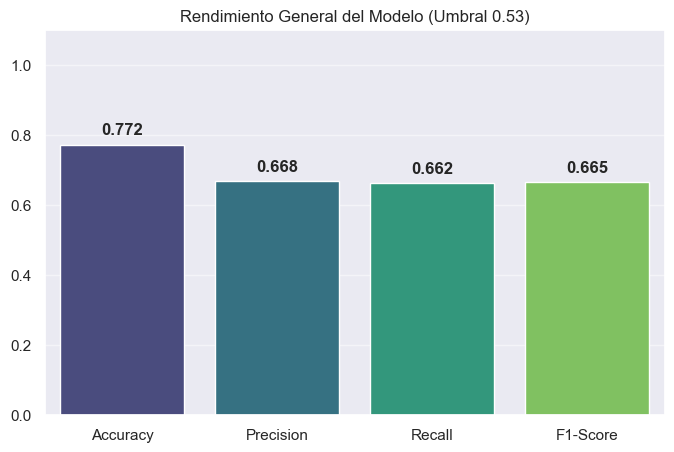

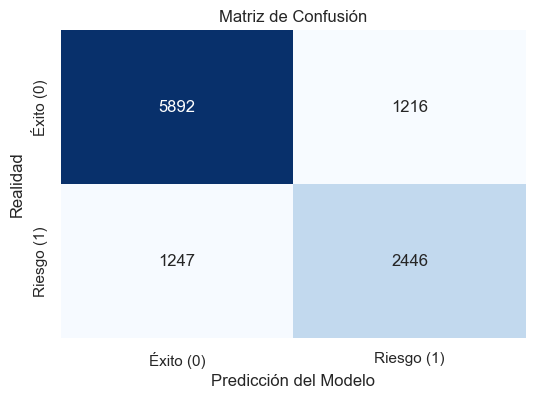

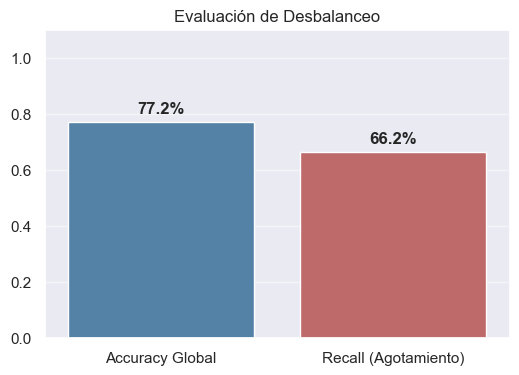

In [14]:
y_probs = xgb_pipeline.predict_proba(X_test)[:, 1]

umbral_permisivo = 0.53
y_pred = (y_probs >= umbral_permisivo).astype(int)

fig1 = plt.figure(figsize=(8, 5))

ax1 = sns.countplot(x=y_test, hue=y_test, palette=['#3CB371', '#CD5C5C'], legend=False)
plt.title('Distribución en Set de Prueba (0: Éxito, 1: Riesgo)')
plt.xticks(ticks=[0, 1], labels=['Éxito (0)', 'Riesgo (1)'])
plt.ylabel('Cantidad')

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"--- REPORTE DE CLASIFICACIÓN DETALLADO (Umbral: {umbral_permisivo}) ---")
print(classification_report(y_test, y_pred, zero_division=0))

fig2 = plt.figure(figsize=(8, 5))
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, prec, rec, f1]
ax2 = sns.barplot(x=metrics_names, y=metrics_values, hue=metrics_names, palette='viridis', legend=False)
plt.title(f'Rendimiento General del Modelo (Umbral {umbral_permisivo})')
plt.ylim(0, 1.1)

for i, v in enumerate(metrics_values):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')
plt.show()

cm = confusion_matrix(y_test, y_pred)
fig3 = plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Éxito (0)', 'Riesgo (1)'],
            yticklabels=['Éxito (0)', 'Riesgo (1)'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad')
plt.show()

report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
burnout_recall = report_dict['1']['recall']

fig4 = plt.figure(figsize=(6, 4))
metric_names_comp = ['Accuracy Global', 'Recall (Agotamiento)']
metric_values_comp = [acc, burnout_recall]
ax4 = sns.barplot(x=metric_names_comp, y=metric_values_comp, hue=metric_names_comp, palette=['#4682B4', '#CD5C5C'],
                  legend=False)
plt.title('Evaluación de Desbalanceo')
plt.ylim(0, 1.1)

for i, v in enumerate(metric_values_comp):
    ax4.text(i, v + 0.02, f"{v * 100:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.show()

## Grid search

In [ ]:
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__min_child_weight': [1, 5, 10],
    'classifier__scale_pos_weight': [1, peso_minoritaria, peso_minoritaria * 1.5, 5, 10]
}

print("Iniciando Grid Search...")
print("Entrenando múltiples combinaciones mediante validación cruzada (CV=3)...")

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n" + "=" * 50)
print("¡BÚSQUEDA FINALIZADA!")
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f" - {param.replace('classifier__', '')}: {value}")
print("=" * 50)

mejor_modelo = grid_search.best_estimator_

umbral_prueba = 0.15
y_probs_grid = mejor_modelo.predict_proba(X_test)[:, 1]
y_pred_grid = (y_probs_grid >= umbral_prueba).astype(int)

print(f"\n--- REPORTE DEL MEJOR MODELO (Umbral: {umbral_prueba}) ---")
print(classification_report(y_test, y_pred_grid, zero_division=0))

print("=" * 65)
print(" BUSCANDO EL UMBRAL ÓPTIMO PARA EL MODELO GANADOR")
print("=" * 65)
print(f"{'Umbral':<8} | {'Accuracy Global':<18} | {'Recall (Riesgo)':<18} | {'Precisión (Riesgo)':<18}")
print("-" * 65)

umbrales_prueba = np.arange(0.30, 0.85, 0.05)

for u in umbrales_prueba:
    y_pred_temp = (y_probs_grid >= u).astype(int)

    acc = accuracy_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp, zero_division=0)
    prec = precision_score(y_test, y_pred_temp, zero_division=0)

    print(f"{u:.2f}     | {acc * 100:>5.1f}%             | {rec * 100:>5.1f}%             | {prec * 100:>5.1f}%")

Iniciando Grid Search...
Entrenando múltiples combinaciones mediante validación cruzada (CV=3)...
Fitting 3 folds for each of 720 candidates, totalling 2160 fits


## SHAP

In [ ]:
import shap

print("\n" + "=" * 65)
print(" GENERANDO EXPLICACIONES DEL MODELO GANADOR CON SHAP")
print("=" * 65)

modelo_puro = mejor_modelo.named_steps['classifier']
preprocesador_ganador = mejor_modelo.named_steps['preprocessor']

X_test_transformado = preprocesador_ganador.transform(X_test)
nombres_columnas = preprocesador_ganador.get_feature_names_out()

X_test_shap = pd.DataFrame(X_test_transformado, columns=nombres_columnas)
X_test_shap.columns = X_test_shap.columns.str.replace(r"[\[\]<]", "_", regex=True)

explainer = shap.TreeExplainer(modelo_puro)
shap_values = explainer.shap_values(X_test_shap)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_shap, plot_type="bar",
                  max_display=X_test_shap.shape[1],
                  show=False)
plt.title("Importancia Global de Características (SHAP)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_shap,
                  max_display=X_test_shap.shape[1],
                  show=False)
plt.title("Impacto de las Variables en el Riesgo de Abandono (SHAP)")
plt.tight_layout()
plt.show()

print("\nGenerando explicación individual (Waterfall Plot)...")
explicacion_completa = explainer(X_test_shap)
indice_estudiante = 0
shap.plots.waterfall(explicacion_completa[indice_estudiante], max_display=10, show=False)
plt.title(f"Desglose Predictivo - Estudiante ID Test: {indice_estudiante}")
plt.tight_layout()
plt.show()